## Libraries

In [1]:
!pip install -q \
  datasets \
  transformers \
  peft \
  huggingface_hub \
  ipywidgets

!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys
import time
import torch
import ipywidgets
from torch.utils.data import Dataset
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from itertools import islice
from huggingface_hub import login
from huggingface_hub import HfFolder
from huggingface_hub import HfApi
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:32" # Allows to split memory into pieces when allocating (normally the GPU VRAM needs a contiguous block of memory). Caps memory block size to maximum of 32 MB

## Load model & dataset

##### Login to huggingface

In [3]:
login()

#### Load base model

The GPU VRAM is not sufficient for training the model. We use LoRA to make it more efficient

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    torch_dtype=torch.float16,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,                          # Rank of the low-rank adapter
    lora_alpha=16,                # Scaling factor
    target_modules=["q_proj", "v_proj"],  # Apply LoRA to attention modules (check model architecture)
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM # Important: for language modeling
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


#### Load fine-tuned model with LoRA adapters

In [4]:
base = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
model = PeftModel.from_pretrained(base, "eduhuemar001/tinyllama-german", is_trainable=True)
tokenizer = AutoTokenizer.from_pretrained("eduhuemar001/tinyllama-german")
model.print_trainable_parameters()
model.base_model_prefix
print(model)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitu

#### Load dataset

In [5]:
streamed_dataset = load_dataset(
    "wikipedia",
    "20220301.de",
    split="train",
    streaming=True,
    trust_remote_code=True
)

dataset = list(islice(streamed_dataset, 20)) # Download wikipedia articles
total_size = sum(sys.getsizeof(item["text"]) for item in dataset)
print(f"Approximate total size of Wikipedia texts: {total_size / 1024**2:.2f} MB")

README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

wikipedia.py:   0%|          | 0.00/36.7k [00:00<?, ?B/s]

Approximate total size of Wikipedia texts: 0.42 MB


## Preprocessing

#### Tokenize data

Each subword is being converted to a token with a byte pair encoder

In [6]:
tokens = []

for item in dataset:
    ids = tokenizer(item["text"], return_attention_mask=False, add_special_tokens=False).input_ids
    tokens.extend(ids + [tokenizer.eos_token_id])  # optional: add EOS after each article

Token indices sequence length is longer than the specified maximum sequence length for this model (4490 > 2048). Running this sequence through the model will result in indexing errors


#### Split tokens into chunks



Documents with a high amount of tokens exceed the maximum context window of 2048 tokens. The documents are split up into chunks of 128 tokens.

In [7]:
block_size = 128
total_length = len(tokens) - (len(tokens) % block_size)
tokens = tokens[:total_length] # Ensure the tokens array has a length of multiple of block size

chunks = [tokens[i:i + block_size] for i in range(0, total_length, block_size)] # Split tokens into chunks

#### Prepare chunks for training

In [8]:
class ChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        return {
            "input_ids": ids,
            "labels": ids
        }

train_dataset = ChunkDataset(chunks)

## Set training arguments

In [9]:
training_args = TrainingArguments(
    output_dir="./tinyllama-german-lora",
    num_train_epochs=2,                      # Less epochs to reduce time
    per_device_train_batch_size=2,           # Efficient batch size without crashing
    gradient_accumulation_steps=2,           # Total batch size = 2 * 2 = 4 (reasonable for tiny dataset)
    learning_rate=2e-4,                      # Slightly more aggressive for fewer epochs
    warmup_steps=5,                          # Just a short warmup
    weight_decay=0.01,                       # Still helpful for generalization
    logging_steps=5,                         # Frequent logs, fast feedback
    save_strategy="epoch",                   # Save after each epoch
    save_total_limit=1,                      # Only last checkpoint saved
    fp16=True,                               # Faster and lower memory
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    # optimizers=(torch.optim.AdamW(model.parameters(), lr=training_args.learning_rate), None), # Remove custom optimizers
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


## Start training loop

#### Start initial training or resume training if checkpoint exists. The checkpoints are saved as long as colab session runs. Save model to huggingface after finished training.

In [10]:
torch.cuda.empty_cache() # Clear GPU memory
torch.cuda.reset_peak_memory_stats()

checkpoint_dir = training_args.output_dir
resume_checkpoint = None

if os.path.isdir(checkpoint_dir):
    checkpoints = [
        os.path.join(checkpoint_dir, d)
        for d in os.listdir(checkpoint_dir)
        if d.startswith("checkpoint")
    ]
    if checkpoints:
        latest = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
        resume_checkpoint = latest

start_time = time.time()
if resume_checkpoint:
    print(f"Resuming from checkpoint: {resume_checkpoint}")
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    print("Starting fresh training...")
    trainer.train()
end_time = time.time()
print(f"Training took {end_time - start_time:.2f} seconds")
print("Training finished — pushing model to Hugging Face Hub...")

# model.push_to_hub("eduhuemar001/tinyllama-german")    # This pushes the base model and the fine-tuned model to huggingface. 2x the size!
# tokenizer.push_to_hub("eduhuemar001/tinyllama-german")

# model = model.merge_and_unload() # Merge LoRA adapters into the base model. LoRA training again will not be possible!

model.save_pretrained("tinyllama-german-lora")      # Save locally
tokenizer.save_pretrained("tinyllama-german-lora")

api = HfApi()
api.upload_folder(
    folder_path="tinyllama-german-lora",
    repo_id="eduhuemar001/tinyllama-german",
    repo_type="model",
    commit_message="Uploading LoRA adapter + base model for continued training."
)

Starting fresh training...


Step,Training Loss
5,1.560000
10,1.787500
15,1.427000
20,1.582600
25,1.617900
30,1.567400
35,1.633400
40,1.491800
45,1.642800
50,1.637000


Training took 101.16 seconds
Training finished — pushing model to Hugging Face Hub...


Upload 6 LFS files:   0%|          | 0/6 [00:00<?, ?it/s]

optimizer.pt:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

adapter_model.safetensors:   0%|          | 0.00/4.52M [00:00<?, ?B/s]

scheduler.pt:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

scaler.pt:   0%|          | 0.00/988 [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/eduhuemar001/tinyllama-german/commit/2ba90b60b28fb8408a8cef8c5ae35853a565f8d3', commit_message='Uploading LoRA adapter + base model for continued training.', commit_description='', oid='2ba90b60b28fb8408a8cef8c5ae35853a565f8d3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/eduhuemar001/tinyllama-german', endpoint='https://huggingface.co', repo_type='model', repo_id='eduhuemar001/tinyllama-german'), pr_revision=None, pr_num=None)

## Appendix

#### Memory usage

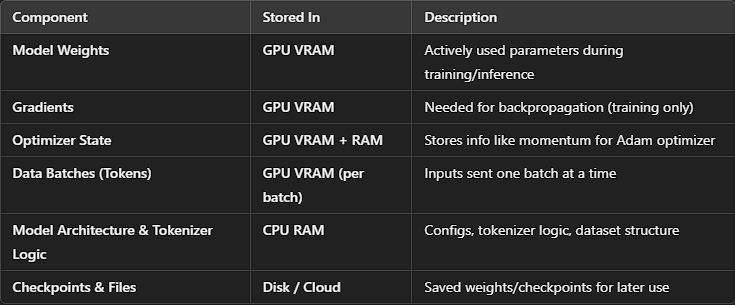